# IBM Quantum hardware run — analysis

Compares three distributions for each tuned QAOA circuit:

- **exact** — noiseless statevector probabilities of the tuned circuit,
- **ideal-simulated** — Aer `SamplerV2`, 4096 shots (adds *shot* noise),
- **hardware** — real backend counts (adds *device* noise), shown only once
  `docs/results/hardware_counts.json` exists (after stage (b)).

Metrics: total-variation distance between distributions (TVD(exact, ideal-sim)
isolates shot noise; TVD(ideal-sim, hardware) ≈ device noise), plus optimal-state
mass and feasibility rate. The optimal-bitstring set comes from the brute-force
optimum.

Targets: primary T=2 and T=3 (seed 0, reps 1 & 2), where the scaling sweep showed
real concentration. Parameters are re-optimized on the simulator in stage (a)
(`hardware_params.json`); nothing here spends QPU.

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
import experiment_hardware as hw

%matplotlib inline

records = json.loads((Path.cwd().parent / "docs" / "results" / "hardware_params.json").read_text())
print(f"{len(records)} tuned circuits loaded")

4 tuned circuits loaded


## Exact vs ideal-simulated

For each target: the exact distribution, an Aer 4096-shot sample, their TVD (the
irreducible shot-noise floor), and each distribution's optimal mass / feasibility.

In [2]:
rows = []
for r in records:
    problem, qubo, ansatz = hw.build_target(r['T'], r['seed'], r['reps'])
    opt_mask, feas_mask = hw.basis_masks(problem, qubo)
    exact = hw.exact_distribution(ansatz, r['params'])
    sim = hw.counts_to_probs(hw.ideal_sim_counts(ansatz, r['params']), r['m'])
    em = hw.scalar_metrics(exact, opt_mask, feas_mask)
    sm = hw.scalar_metrics(sim, opt_mask, feas_mask)
    rows.append({'label': f"T{r['T']}/reps{r['reps']}", 'm': r['m'],
                 'exact': exact, 'sim': sim, 'opt_mask': opt_mask, 'feas_mask': feas_mask,
                 'tvd_shot': hw.tv_distance(exact, sim),
                 'em': em, 'sm': sm})

print(f"{'target':>11} {'m':>3} {'exact_mass':>10} {'sim_mass':>9} {'TVD(shot)':>10} {'exact_feas':>10} {'sim_feas':>9}")
for x in rows:
    print(f"{x['label']:>11} {x['m']:>3} {x['em']['optimal_mass']:>10.4f} {x['sm']['optimal_mass']:>9.4f} "
          f"{x['tvd_shot']:>10.4f} {x['em']['feasibility']:>10.4f} {x['sm']['feasibility']:>9.4f}")

/home/anna/quantum-solar/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/anna/quantum-solar/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/anna/quantum-solar/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


/home/anna/quantum-solar/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/anna/quantum-solar/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/anna/quantum-solar/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


     target   m exact_mass  sim_mass  TVD(shot) exact_feas  sim_feas
   T2/reps1   6     0.0288    0.0315     0.0422     0.2336    0.2334
   T2/reps2   6     0.0011    0.0012     0.0400     0.1984    0.1973
   T3/reps1  10     0.0001    0.0000     0.1407     0.0851    0.0852
   T3/reps2  10     0.0009    0.0007     0.1594     0.0874    0.0857


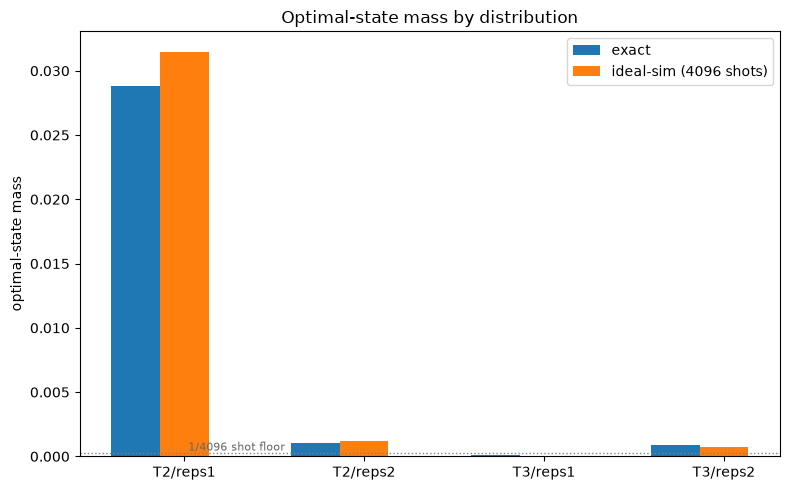

In [3]:
import matplotlib.pyplot as plt

# Hardware counts path; override with QS_HARDWARE_COUNTS (used by the stage-(c)
# dress rehearsal to point at a synthetic file without touching the real path).
hw_path = Path(os.environ.get('QS_HARDWARE_COUNTS',
                              Path.cwd().parent / 'docs' / 'results' / 'hardware_counts.json'))
have_hw = hw_path.exists()
hw_by_key = {}
if have_hw:
    hwdata = json.loads(hw_path.read_text())
    for res in hwdata['results']:
        hw_by_key[(res['T'], res['reps'])] = res['counts']
    print(f"hardware: backend={hwdata['backend']} actual_qpu_seconds={hwdata.get('actual_qpu_seconds')}")

labels = [x['label'] for x in rows]
exact_mass = [x['em']['optimal_mass'] for x in rows]
sim_mass = [x['sm']['optimal_mass'] for x in rows]
xi = np.arange(len(rows)); w = 0.27
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(xi - w, exact_mass, w, label='exact')
ax.bar(xi, sim_mass, w, label='ideal-sim (4096 shots)')
if have_hw:
    hw_mass = []
    for r, x in zip(records, rows):
        c = hw_by_key.get((r['T'], r['reps']))
        p = hw.counts_to_probs(c, r['m']) if c else np.zeros(2**r['m'])
        hw_mass.append(hw.scalar_metrics(p, x['opt_mask'], x['feas_mask'])['optimal_mass'])
    ax.bar(xi + w, hw_mass, w, label='hardware')
ax.axhline(1/4096, color='0.5', ls=':', lw=1); ax.text(0, 1/4096, ' 1/4096 shot floor', fontsize=8, va='bottom', color='0.4')
ax.set_xticks(xi); ax.set_xticklabels(labels)
ax.set_ylabel('optimal-state mass'); ax.set_title('Optimal-state mass by distribution')
ax.legend(); fig.tight_layout()

## Hardware (fills after stage (b))

Once `docs/results/hardware_counts.json` exists, this cell reports the device-noise
distances TVD(exact, hardware) and TVD(ideal-sim, hardware) and the hardware
optimal mass / feasibility. Until then it notes that no QPU run has been recorded.

In [4]:
if not have_hw:
    print('No hardware_counts.json yet. Run stage (b):')
    print('  python scripts/experiment_hardware.py submit                 # dry run (summary only)')
    print('  python scripts/experiment_hardware.py submit --yes-spend-qpu  # actually samples on hardware')
else:
    print(f"{'target':>11} {'TVD(exact,hw)':>14} {'TVD(sim,hw)':>12} {'hw_mass':>9} {'hw_feas':>9}")
    for r, x in zip(records, rows):
        c = hw_by_key.get((r['T'], r['reps']))
        if not c:
            continue
        p = hw.counts_to_probs(c, r['m'])
        hm = hw.scalar_metrics(p, x['opt_mask'], x['feas_mask'])
        print(f"{x['label']:>11} {hw.tv_distance(x['exact'], p):>14.4f} {hw.tv_distance(x['sim'], p):>12.4f} "
              f"{hm['optimal_mass']:>9.4f} {hm['feasibility']:>9.4f}")

No hardware_counts.json yet. Run stage (b):
  python scripts/experiment_hardware.py submit                 # dry run (summary only)
  python scripts/experiment_hardware.py submit --yes-spend-qpu  # actually samples on hardware


## Reading this

**TVD(exact, ideal-sim)** is the irreducible shot-noise floor at 4096 shots — the
best any hardware run could match. **TVD(ideal-sim, hardware)** (once available)
is the device-noise contribution on top of it. The optimal-mass bars show how much
of the (already thin) ideal concentration survives shot noise and then device
noise; the depth comparison (reps 1 vs 2) shows whether a deeper circuit's extra
device noise outweighs any concentration gain.

These primary instances are chosen precisely because their ideal optimal mass is
measurable (largest at T=2/reps 1); the 22-qubit stretch, if run, carries no
success signal even ideally, so any hardware distribution there is uninterpretable
by design — it is a device-behavior curiosity, not a result.